#Sección Operadores

## Preprocesamiento

Para empezar con el preprocesamiento de los datos, la idea a la que llegué pasa por los siguientes puntos:


1.   Cargar las imágenes al archivo ipynb, desde una carpeta en drive, para evitar tener que subirlas a los archivos temporales de Google Colab cada vez que se vaya a trabajar. Dichas imágenes estarán es carpetas separadas por cada operador, de la forma, por ejemplo: suma o division2. Las terminadas en 2, serán para los operadores de multiplicación y división, puesto que tenemos dos variantes. De esta forma, podemos seguir agregando muestras, sin importar el nombre que se le den a cada archivo.
2.   Una vez cargadas, pasaremos todas las imágenes a la resolución $28 \times 28$, y muy importante a escala de grises, de esta forma el dataset que creemos estará alineado con el de MNIST. Para ello usaremos una función otorgada en el archivo image_processing.py, que justamente nos convierte inteligentemente nuestras imágenes en unas del estilo MNIST.
3.  Con la idea proporcionada por el profesor, convertiremos estas imágenes en una matriz y las aplanaremos teniendo un vector de 784 características, aquí es donde entendemos por qué pasarlo a escala de grises, pues si lo dejaramos en RGB, tendríamos un cubo de $28 \times 28 \times 3$.






Pero acá nos surge una problemática y es generar las imágenes. Hacerlo de forma manual es mucho trabajo, por lo que generé manualmente 10 imágenes de cada símbolo y gracias a buscar un poco por internet, llegué a la idea de hacer data augmentation.

Puesto que, si tenemos muy pocos datos con tantas características tendremos sobre ajuste, esto lo podemos solucionar aumentando nuestra cantidad de datos. La idea viene de esta página que me encontré https://akanshasaxena.com/challenge/deep-learning/day-10/, donde usando un dataset de MNIST pero de articulos de ropa, hacen uso del data augmentation para solucionar ciertos problemas. Pero, como nosotros no estamos usando un dataset de MNIST para los operadores, adaptaremos una función que nos haga este aumento de los datos.

Para ello el siguiente código basándonos en la firma del método ImageDataGenerator de Keras usado en el link previo, tenemos:

In [2]:
# Importaciones

# Carga del drive y librerías a usar
from google.colab import drive
import os # Para poder movernos en las carpetas
import cv2 # Para leer las imágenes
import numpy as np
import pandas as pd

# Montamos google drive
drive.mount('/content/drive')
# Cargamos la ruta de la carpeta dentro del drive
ruta_operadores = '/content/drive/MyDrive/ML/Tarea2/Operadores'

Mounted at /content/drive


In [3]:
import random
def aplicar_aumento(imagen):
    h, w = imagen.shape[:2]

    # Sabiendo que en la aplicación se puede cambiar el color del fondo de la imagen, para evitarnos errores tomamos el color de fondo para generar los nuevos pixeles cuando movamos o rotemos la img
    color_dinamico = tuple(int(c) for c in imagen[0, 0])

    # Rotamos aleatoriamente
    angulo = random.uniform(-10, 10)
    matriz_rot = cv2.getRotationMatrix2D((w/2, h/2), angulo, 1.0)
    img_rot = cv2.warpAffine(imagen, matriz_rot, (w, h), borderValue=color_dinamico)

    # Movemos aleatoriamente
    tx = random.randint(-4, 4)
    ty = random.randint(-4, 4)
    matriz_trans = np.float32([[1, 0, tx], [0, 1, ty]])
    img_trans = cv2.warpAffine(img_rot, matriz_trans, (w, h), borderValue=color_dinamico)

    # Acercamos o alejamos la imagen un poco
    escala = random.uniform(0.9, 1.1)
    nuevo_w, nuevo_h = int(w * escala), int(h * escala)
    img_zoom = cv2.resize(img_trans, (nuevo_w, nuevo_h))

    if escala > 1.0:
        y_inicio = (nuevo_h - h) // 2
        x_inicio = (nuevo_w - w) // 2
        img_final = img_zoom[y_inicio:y_inicio+h, x_inicio:x_inicio+w]
    else:
        pad_y = (h - nuevo_h) // 2
        pad_x = (w - nuevo_w) // 2
        img_final = cv2.copyMakeBorder(img_zoom, pad_y, h - nuevo_h - pad_y,
                                       pad_x, w - nuevo_w - pad_x,
                                       cv2.BORDER_CONSTANT, value=color_dinamico)

    img_final = cv2.resize(img_final, (w, h))
    return img_final

objetivo_por_clase = 50  # Esto nos da cuantas imagenes querremos por clase

# Proceso de data augmentation por clase
for carpeta in os.listdir(ruta_operadores):
    ruta_carpeta = os.path.join(ruta_operadores, carpeta)

    if not os.path.isdir(ruta_carpeta):
        continue

    archivos_originales = [f for f in os.listdir(ruta_carpeta) if f.endswith(('.png', '.jpg', '.jpeg'))]
    cantidad_actual = len(archivos_originales)

    if cantidad_actual == 0:
        continue

    faltantes = objetivo_por_clase - cantidad_actual

    if faltantes <= 0:
        continue

    for i in range(faltantes):
        # Elegir una imagen original al azar para clonarla
        archivo_base = random.choice(archivos_originales)
        ruta_base = os.path.join(ruta_carpeta, archivo_base)

        imagen = cv2.imread(ruta_base)
        if imagen is None:
            continue

        # Generar el clon mutado
        imagen_aumentada = aplicar_aumento(imagen)

        # Guardar el nuevo archivo con un nombre único
        nuevo_nombre = f"aug_{i}_{archivo_base}"
        ruta_nueva = os.path.join(ruta_carpeta, nuevo_nombre)
        cv2.imwrite(ruta_nueva, imagen_aumentada)

Una vez hecho el aumento de los datos, hablemos de ciertas consideraciones que tomamos:



1.   Color de fondo: Desde la aplicación las imágenes pueden tener distintos colores de fondo, si bien entiendo que más adelante eso será indiferente, al momento de crear los nuevos datos, no podemos tener píxeles que pertenecen a la imagen de un color distinto, pues al pasar a escala de grises, esto podría generar problemas.
2.   Variar las imágenes: Al momento de modificar las imágenes debemos hacerlo con cabeza, por ello no tiene sentido que un símbolo $-$ lo rotemos tanto que parezca un $/$. Por eso se establecieron límites a las operaciones que ibamos a hacer.
3.   Ayuda: Para hacer todo este código de data augmentation usé la LLM de Google, Gemini, esto debido a que nunca había trabajado con imágenes de esta forma.




Ahora bien, utilizando el código base proporcionado en la carpeta utils del proyecto, podemos hacer el preprocesamiento mencionado fácilmente.

[Link de las imágenes](https://drive.google.com/drive/folders/1EdYJ01SVNl157KESuDkde7d8RxVCtYfo?usp=drive_link)


In [4]:
# Reutilizamos la función clave
def transform_image_to_mnist(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Transform a canvas export image to MNIST-compatible 28x28 format.

    Matches MNIST conventions:
    - 28x28 grayscale
    - Background = 0 (black)
    - Digit/symbol strokes = white (up to 255)
    - Content is cropped and centered with padding (like MNIST)
    - Soft anti-aliased edges preserved (no binary thresholding)

    Args:
        image: Input image as numpy array (H, W, C) — RGB from PIL.

    Returns:
        Tuple of (processed_image, equalized_image) both 28x28 uint8.
    """
    # Remove alpha channel if present
    if len(image.shape) == 3 and image.shape[2] == 4:
        image = image[:, :, :3]

    # Convert RGB to grayscale
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()

    # Determine if strokes are lighter or darker than background.
    # Sample corners to estimate background value.
    h, w = gray.shape
    corners = [gray[0, 0], gray[0, w - 1], gray[h - 1, 0], gray[h - 1, w - 1]]
    bg_value = int(np.median(corners))

    # Make background black, strokes white (like MNIST)
    if bg_value > 127:
        # Light background, dark strokes → invert
        gray = 255 - gray
    else:
        # Dark background, light strokes → subtract background
        gray = gray.astype(np.int16) - bg_value
        gray = np.clip(gray, 0, 255).astype(np.uint8)

    # Crop to bounding box of the drawn content (non-zero pixels)
    # This ensures the digit fills the frame like MNIST digits do.
    threshold = 20  # ignore faint noise
    coords = np.argwhere(gray > threshold)

    if coords.size == 0:
        # Nothing drawn — return blank 28x28
        blank = np.zeros((28, 28), dtype=np.uint8)
        return blank, blank

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    # Extract the content region
    cropped = gray[y_min:y_max + 1, x_min:x_max + 1]

    # Fit into a square (MNIST digits are centered in a square)
    ch, cw = cropped.shape
    side = max(ch, cw)
    square = np.zeros((side, side), dtype=np.uint8)
    y_offset = (side - ch) // 2
    x_offset = (side - cw) // 2
    square[y_offset:y_offset + ch, x_offset:x_offset + cw] = cropped

    # Add padding (~4px equivalent at 28x28 = ~14% border, matching MNIST)
    pad = max(side // 6, 2)
    padded = np.zeros((side + 2 * pad, side + 2 * pad), dtype=np.uint8)
    padded[pad:pad + side, pad:pad + side] = square

    # Resize to 28x28 with anti-aliasing preserved
    resized = cv2.resize(padded, (28, 28), interpolation=cv2.INTER_AREA)

    # Equalized version
    equalized = cv2.equalizeHist(resized)

    return resized, equalized



EDIT: Después de realizar todo el entrenamiento, al entrar en la app, específicamente al archivo game_state.py. Me di cuenta que como mapeaba los símbolos era del 0 al 5. Por eso cambié la app para que los mapee con su codigo ASCII y no explote.


In [5]:
# Creamos una estructura para mapear las carpetas, y les asignamos el valor ascii del operador a usar
clases_map = {
    'suma': 43, # +
    'resta': 45, # -
    'multiplicacion': 215, # x
    'multiplicacion2': 42, # *
    'division': 247, # ÷
    'division2': 47 # /
}

# Creamos la matriz X y el vector Y (caracteristicas y clases)
caracteristicas = []
clases = []

for folder_name, ascii_code in clases_map.items():
    folder_path = os.path.join(ruta_operadores, folder_name)

    # Procesamos cada imagen
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        # Leer la imagen, esta funcion normalmente lee en formato BGR, por lo que debemos convertirla a RGB para que la aplicación no explote
        image = cv2.imread(file_path)

        # Convertir a RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Pasamos la imagen a la función proporcionada
        _, processed_img = transform_image_to_mnist(image_rgb)

        # Aplanamos la matriz en un vector
        flattened_img = processed_img.flatten()

        # Guardamos los resultados
        caracteristicas.append(flattened_img)
        clases.append(ascii_code)

# Convertimos en estructuras de numpy
X = np.array(caracteristicas)
y = np.array(clases)

# Lo metemos en un dataframe para verlo bonito
df_operadores = pd.DataFrame(X)
df_operadores['etiqueta'] = y

# Exportamos el dataset
df_operadores.to_csv('dataset_operadores.csv', index=False)

print(f"Dimensiones de X (Imágenes): {X.shape}")
print(f"Dimensiones de y (Etiquetas): {y.shape}")

Dimensiones de X (Imágenes): (300, 784)
Dimensiones de y (Etiquetas): (300,)


También, acá está el dataset subido al repositorio y cargado desde el mismo:

In [ ]:
url_github = "https://raw.githubusercontent.com/JD1714/tarea2-ml/refs/heads/main/models/input/dataset_operadores.csv"

df_operadores_github = pd.read_csv(url_github)

y = df_operadores['etiqueta'].values

X = df_operadores.drop('etiqueta', axis=1).values

In [6]:
df_operadores

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,etiqueta
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,43
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,43
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,43
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,43
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,47
296,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,47
297,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,47
298,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,47


Con esto ya tendríamos nuestro dataset creado, como se puede en el código posterior, vemos las clases de cada entrada. Recordemos que tenemos imágenes del estilo MNIST, fondo oscuro con trazos claros.

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
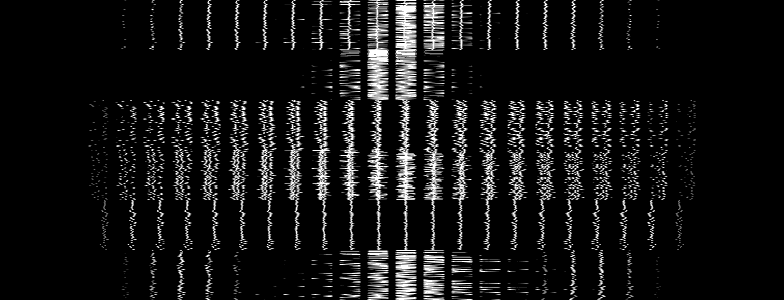

In [7]:
X

In [8]:
y

array([ 43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,
        43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,
        43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,
        43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  45,  45,
        45,  45,  45,  45,  45,  45,  45,  45,  45,  45,  45,  45,  45,
        45,  45,  45,  45,  45,  45,  45,  45,  45,  45,  45,  45,  45,
        45,  45,  45,  45,  45,  45,  45,  45,  45,  45,  45,  45,  45,
        45,  45,  45,  45,  45,  45,  45,  45,  45, 215, 215, 215, 215,
       215, 215, 215, 215, 215, 215, 215, 215, 215, 215, 215, 215, 215,
       215, 215, 215, 215, 215, 215, 215, 215, 215, 215, 215, 215, 215,
       215, 215, 215, 215, 215, 215, 215, 215, 215, 215, 215, 215, 215,
       215, 215, 215, 215, 215, 215, 215,  42,  42,  42,  42,  42,  42,
        42,  42,  42,  42,  42,  42,  42,  42,  42,  42,  42,  42,  42,
        42,  42,  42,  42,  42,  42,  42,  42,  42,  42,  42,  4

Ahora vamos a seguir con el preprocesamiento, si notamos bien nuestra matriz $X$, tiene valores de 0 a 255. Modelos como los de Regresión logística son sumamente sensibles a estos extremos de valores, por lo que, vamos a escalarla, para que los valores pasen a ser entre 0 y 1. Además investigando un poco, esto también se vuelve un paso crucial al momento de usar K-NN y SVM, sin embargo es indiferente para Árboles de decisión. Para lograr lo mencionado previamente, no haremos más que cada elemento entre 255.

Referencias sobre cuando escalar:
  
*   Sobre K-NN y Árboles de decisión: https://codificandobits.com/tutorial/por-que-cuando-escalar-los-datos/ (Sección: *Efecto del escalamiento en diferentes modelos de Machine Learning* )
*   Sobre SVM: https://interactivechaos.com/es/manual/tutorial-de-machine-learning/escalado



In [9]:
from sklearn.model_selection import train_test_split # Aprovecharemos también de separar nuestro dataset
semilla_cedula = 30136061

# Escalamos
X_escalada = X/255.0
# Dividimos en test y train
X_train, X_test, y_train, y_test = train_test_split(X_escalada, y, test_size=0.30, random_state=semilla_cedula, stratify=y)

print(f"Cantidad entrenamiento: {X_train.shape[0]}")
print(f"Cantidad test: {X_test.shape[0]}")

Cantidad entrenamiento: 210
Cantidad test: 90


## Entrenamiento

Pasando al entrenamiento, para obtener un buen modelo debemos evitar el sobreajuste, y para ello pasamos por las técnicas de regularización que cada modelo tiene. Así que vayamos uno a uno:

### Regresión Logística:

En los modelos de Regresión Logística, podemos usar las técnicas de regularización vistas en clases, pero con un ligero cambio. Pues en esta, el parámetro de regularización es $C$, donde este no es más que $C = 1/\lambda$, siendo $\lambda$ el parámetro de regularización visto en la teoria.

Referencias para $C$: https://dev.to/jesus_oviedoriquelme_084/mlzc25-22-regularizacion-en-regresion-logistica-ajuste-fino-del-parametro-c-para-mejor-26gl

Ahora bien, al momento de decidir que regularización usar, pensemos en que hace cada una:

*   Lasso: Llevar variables exactamente a 0, "matarlas".
*   Ridge: Reducir dichas variables lo más pequeño posible, quitarles peso.

Si analizamos esto, usar Lasso podría llegar a ser peligroso, pues sabemos que nuestros datos provienen de imágenes. Un pixel suele tener relación con los píxeles que lo rodean, lo que puede causar colinealidad. Lasso al ver esto, podría pensar que esos píxeles le dan la misma información, por lo tanto se quedaría con unos pocos y descartaría el resto. Por lo que si después la aplicación recibe un símbolo un tanto distinto a los que fueron usados en entrenamiento, el modelo podría fracasar. Mientras que por parte de Ridge, al ver píxeles que presentan colinealidad, distribuye el peso de la variable entre todos los involucrados, lo que resulta en que en vez de quedarnos con pocos píxeles informativos, dependamos más de la forma general del símbolo.

Con esto, decidimos quedarnos con la Regularización de Ridge, por lo que pasemos al entrenamiento:



In [10]:
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression # Modelo de RL
from sklearn.model_selection import cross_val_score # Lo usaremos para hallar el C
from sklearn.metrics import accuracy_score, classification_report # Métricas para comparar más adelante, con classification report sacaremos las métricas del F1 score, la precisión y la sensibilidad

# Posibles valores de regularización, recordemos que C pequeño es mucha regularización
posibles_C = [0.01, 0.1, 1, 10, 100, 1000]
promedios = []

for c in posibles_C:
    # Creamos el modelo
    modelo_rl = LogisticRegression(C=c, max_iter=1000, random_state=semilla_cedula)
    # Hacemos la validación cruzada
    scores = cross_val_score(modelo_rl, X_train, y_train, cv=5, scoring='accuracy')
    # Calculamos el promedio y lo guardamos
    score_medio = np.mean(scores)
    promedios.append(score_medio)

# Buscamos el mejor
mejor_c = posibles_C[np.argmax(promedios)]
print(f"Mejor C RL: {mejor_c}")

# Entrenamos el modelo
modelo_rl_final = LogisticRegression(C=mejor_c, max_iter=1000, random_state=semilla_cedula)
modelo_rl_final.fit(X_train, y_train)

# Hacemos el test
y_pred_rl = modelo_rl_final.predict(X_test)

# Resultados
precision_rl = accuracy_score(y_test, y_pred_rl)
print(f"Precisión del modelo RL: {precision_rl}")
print(classification_report(y_test, y_pred_rl, zero_division=0)) # Usamos zero_division para evitar unos warnings molestos cuando no logra predecir una clase.

# Almacenamos para comparar futuro
clasificacion_rl = classification_report(y_test, y_pred_rl, zero_division=0)


Mejor C RL: 1
Precisión del modelo RL: 0.9666666666666667
              precision    recall  f1-score   support

          42       1.00      0.80      0.89        15
          43       1.00      1.00      1.00        15
          45       1.00      1.00      1.00        15
          47       1.00      1.00      1.00        15
         215       0.83      1.00      0.91        15
         247       1.00      1.00      1.00        15

    accuracy                           0.97        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.97      0.97      0.97        90



Como se puede observar en las métricas finales, presentamos métricas generales bastante buenas, perfectas para muchas de las clases. Pero analizando esto con más detalles, las clases pertenecientes a los símbolos $*$ y $\times$ (clase 42 y 215 respectivamente), tienen una relación curiosa, donde una falla en el recall (sensiblidad) la otra falla en la precisión, es decir donde la clase 42 predijo todos sus simbolos correctamente, también "se llevó por el medio" o "robó" predicciones a la clase 215, por lo que la precisión de esta última se vio reducida. Y si pensamos en la forma de ambos símbolos, tiene sentido que al modelo le cueste reconocerlos, pues si del $*$ se nos van alguno de los trazos internos muy cortos, va a parecer más un $\times$. Esto lo veremos mucho mejor al graficar la matriz de confusión asociada en un heatmap.

También denotemos acá que, las métricas de macro avg y weighted avg, son métricas que evalúan el rendimiento general del modelo. No son más que los promedios de cada métrica. Para el caso de macro, es el promedio de la métrica de las 6 clases, y con respecto al weigthed, es el promedio ponderado, que para este caso es inutil, pues como construimos el dataset, tenemos un perfecto balance de clases, haciendo que sea igual al macro avg.

Como mencionamos previamente, visualicemos esto mejor en el gráfico.



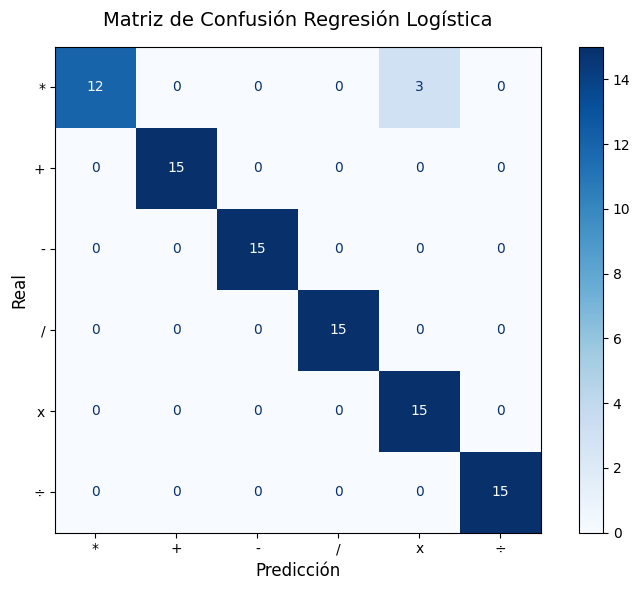

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clases_ascii = [42, 43, 45, 47, 215, 247]
simbolos = ['*', '+', '-', '/', 'x', '÷'] # En el mismo orden que los códigos ascii

matriz_confusion = confusion_matrix(y_test, y_pred_rl, labels=clases_ascii)
fig, ax = plt.subplots(figsize=(8, 6))

# Heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=simbolos)
disp.plot(cmap='Blues', ax=ax, values_format='d')

# Gráfico
plt.title('Matriz de Confusión Regresión Logística', fontsize=14, pad=15)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Ahora analizando el gráfico, en el eje $x$ tenemos la predicción de nuestro modelo, mientras que en el eje $y$ tenemos el valor real, por lo tanto en la diagonal tenemos las predicciones acertadas, y todo fuera de esta será un error, esto proveniente del 30% que usamos para prueba (90 símbolos de 300 de la muestra total), esto es importante destacarlo puesto que usaremos este estilo de gráficos en lo que nos resta. Note que la precisión en los símbolos es casi perfecta, pero que justamente como mencionamos, podemos ver que las predicciones de la clase 42 que se escapan de la diagonal, caen justo en columna asociada al símbolo $\times$, que es justamente lo que mencionamos previamente. Este caso tan claro nos servirá de referencia para el resto de gráficos.

Note también que en este gráfico, realmente lo que estamos graficando es el Recall (Sensibilidad), es decir, la capacidad de hacer predicciones que sean reales.

### K-NN

Ahora bien, para el modelo de K-NN, no tenemos una regularización como tal, sino que contaría como regularización al parámetro $k$, de la cantidad de vecinos a consultar. Con respecto a esta "penalización", como vimos en el parcial 1 de la materia, tomar un $k$ par sería totalmente inutil, pues podríamos caer en un empate y no clasificar nada. Por lo que, para conseguir el mejor $k$ solo consideraremos números impares. Además, en estos métodos K-NN, podemos variar la distancia con la calculamos, sea $p=2$ para la distancia euclideana, o $p=1$ para la distancia Manhattan. Debido a esto, también validaremos el $p$.



In [12]:
from sklearn.neighbors import KNeighborsClassifier

valores_k = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
valores_p = [1, 2]
promedios_knn = []

# Lo que buscamos
mejor_k = None
mejor_p = None
mejor_score = 0

for p in valores_p:
  for k in valores_k:
      modelo_knn = KNeighborsClassifier(n_neighbors=k, p=p)
      scores = cross_val_score(modelo_knn, X_train, y_train, cv=5, scoring='accuracy')
      score_medio = np.mean(scores)

      print(f"  k={k} | p={p} -> Promedio Score: {score_medio}")

      if score_medio > mejor_score:
            mejor_score = score_medio
            mejor_k = k
            mejor_p = p


print(f"Mejor K: {mejor_k}")
if mejor_p == 1:
  print("Mejor distancia: Manhattan")
else:
  print("Mejor distancia: Euclideana")

# Entrenamos el modelo
knn_final =  KNeighborsClassifier(n_neighbors=mejor_k, p=mejor_p)
knn_final.fit(X_train, y_train)

# Hacemos el test
y_pred_knn = knn_final.predict(X_test)

# Resultados
precision_knn = accuracy_score(y_test, y_pred_knn)
print(f"Precisión del modelo KNN: {precision_knn}")
print(classification_report(y_test, y_pred_knn, zero_division=0)) # Usamos zero_division para evitar unos warnings molestos cuando no logra predecir una clase.

# Almacenamos para comparar futuro
clasificacion_knn = classification_report(y_test, y_pred_knn, zero_division=0)


  k=1 | p=1 -> Promedio Score: 0.9571428571428571
  k=3 | p=1 -> Promedio Score: 0.9
  k=5 | p=1 -> Promedio Score: 0.8523809523809524
  k=7 | p=1 -> Promedio Score: 0.8428571428571429
  k=9 | p=1 -> Promedio Score: 0.8
  k=11 | p=1 -> Promedio Score: 0.7761904761904762
  k=13 | p=1 -> Promedio Score: 0.7666666666666666
  k=15 | p=1 -> Promedio Score: 0.7476190476190476
  k=17 | p=1 -> Promedio Score: 0.7238095238095238
  k=19 | p=1 -> Promedio Score: 0.719047619047619
  k=21 | p=1 -> Promedio Score: 0.7095238095238096
  k=1 | p=2 -> Promedio Score: 0.9761904761904763
  k=3 | p=2 -> Promedio Score: 0.9238095238095239
  k=5 | p=2 -> Promedio Score: 0.9047619047619048
  k=7 | p=2 -> Promedio Score: 0.880952380952381
  k=9 | p=2 -> Promedio Score: 0.8571428571428573
  k=11 | p=2 -> Promedio Score: 0.8380952380952381
  k=13 | p=2 -> Promedio Score: 0.819047619047619
  k=15 | p=2 -> Promedio Score: 0.7904761904761904
  k=17 | p=2 -> Promedio Score: 0.7714285714285714
  k=19 | p=2 -> Promedi

Como podemos ver en el cuadro, este modelo se comportó peor que el de regresión logística, y esto se puede deber a que para nuestro dataset tenemos demasiadas características, lo que hace que calcular las distancias entre los datos sea más problemático. Referencia: https://www.servicenow.com/latam/ai/what-is-k-nearest-neighbors-algorithm.html#what-are-the-disadvantages-of-using-the-knn-algorithm (Sección ¿Cuáles son las desventajas?).

A pesar de esto, tenemos un caso interesante, el del símbolo $-$ (clase 45), este tuvo una precisión de 0.88 pero un recall (sensibilida) de 1, eso quiere decir que si tuvo fallos (hizo predicciones de más), pero no dejó pasar ningún $-$. Lo mismo le pasó al símbolo $\times$ (clase 215). Otro caso a destacar, es el relacionado con las clases 42 y 43 (símbolos $*$ y $+$) , pues estas tuvieron una precisión perfecta, pero un recall considerablemente bajo, y esto se explica con el extremo contrario que planteamos previamente, pues esto signfica que hizo pocas predicciones, todas acertadas, pero no alcanzó a encontrar todos los símbolos que realmente pertenecen a ellos.

Otra cosa interesante, es que en este algoritmo resultó ganador la distancia Euclideana y que solo busca en un vecino ($k=1$). Lo que podemos traducir en que el algoritmo confiaba ciegamente en el vecino más cercano, en vez de preguntar a más vecinos. Además note en el bucle, agregamos un debugging para demostrar que a medida que aumentábamos los vecinos, la calidad iba cayendo.

Para este caso, que presenta métricas más pobres que el previo es difícil saber quien "le robó" a quien. Eso lo veremos mejor en el heatmap.

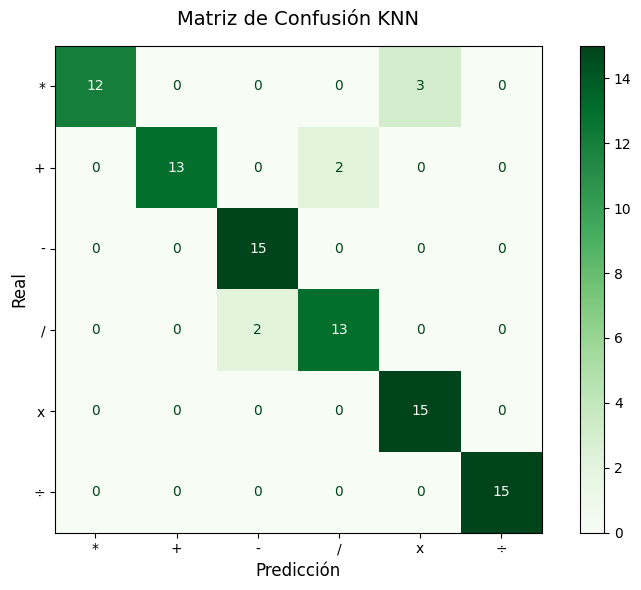

In [13]:
matriz_confusion_knn = confusion_matrix(y_test, y_pred_knn, labels=clases_ascii)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_knn, display_labels=simbolos)
disp.plot(cmap='Greens', ax=ax, values_format='d')

plt.title('Matriz de Confusión KNN', fontsize=14, pad=15)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Viendo el heatmap, tenemos que:

1.  La clase asociada al símbolo $*$ sigue siendo problemática, y de igual manera que con el modelo anterior, sus errores van asociados a los de la clase del símbolo $\times$.
2.  Debemos sumar que ahora la clase del símbolo $+$, empieza a fallar sus predicciones, donde algunos de estos símbolos están siendo confundidos con el símbolo $/$. Cosa que hace sentido, puesto que si la barra horizontal que cruza a dicho símbolo, se hace muy fina, o corta, el modelo podría simplemente ignorarla, y pensar que solo tenemos una barra vertical.
3.  Y por último, el símbolo $/$ está siendo confundido con el símbolo $-$, y este error se podría entender viendo como aumentamos los datos, pues si un símbolo de resta, lo rotamos de más, podría llegar "levantarse" y estar más orientado verticalmente que horizontalmente. Lo mismo pasa si "acostamos" mucho un símbolo de división $/$.

### SVM

Ahora al momento de enfrentarnos a las SVM, gracias a los dos modelos previos podemos intuir que vamos a necesitar una SVM de soft-marging, muy probablemente estas clases no sean perfectamente separables. A su vez, como vimos en clases, el parámetro de regularización de este modelo es $C$, donde un $C >> 0$ casi no aplica regularización, y un $C$ pequeño es una regularización muy fuerte. También tenemos el truco del Kernel, donde usaremos los mismos kernel presentes en la aplicación hecha por el grupo docente, por lo que teniendo estas dos consideraciones, haremos un código bastante parecido al usado en el modelo KNN.

In [14]:
from sklearn.svm import SVC

valores_c_svm = [0.01, 0.1, 1, 10, 100]
valores_kernel = ['linear', 'rbf', 'poly', 'sigmoid']

mejor_score_svm = 0
mejor_c_svm = None
mejor_kernel = None

for k in valores_kernel:

    for c in valores_c_svm:
        modelo_svm = SVC(C=c, kernel=k, random_state=semilla_cedula)

        scores = cross_val_score(modelo_svm, X_train, y_train, cv=5, scoring='accuracy')
        score_medio = np.mean(scores)

        print(f"  C={c}, Kernel={k} -> Promedio: {score_medio}")

        # Guardamos el mejor resultado
        if score_medio > mejor_score_svm:
            mejor_score_svm = score_medio
            mejor_c_svm = c
            mejor_kernel = k

print(f"Mejor C: {mejor_c_svm}")
print(f"Mejor kernel: {mejor_kernel}")

# Entrenamos el modelo
svm_final = SVC(C=mejor_c_svm, kernel=mejor_kernel, random_state=semilla_cedula)
svm_final.fit(X_train, y_train)

# Hacemos el test
y_pred_svm = svm_final.predict(X_test)

# Resultados
precision_svm = accuracy_score(y_test, y_pred_svm)
print(f"Precisión del modelo SVM: {precision_svm}")
print(classification_report(y_test, y_pred_svm, zero_division=0)) # Usamos zero_division para evitar unos warnings molestos cuando no logra predecir una clase.

# Almacenamos para comparar futuro
clasificacion_svm = classification_report(y_test, y_pred_svm, zero_division=0)

  C=0.01, Kernel=linear -> Promedio: 0.9428571428571428
  C=0.1, Kernel=linear -> Promedio: 0.9857142857142858
  C=1, Kernel=linear -> Promedio: 0.9857142857142858
  C=10, Kernel=linear -> Promedio: 0.9857142857142858
  C=100, Kernel=linear -> Promedio: 0.9857142857142858
  C=0.01, Kernel=rbf -> Promedio: 0.8904761904761905
  C=0.1, Kernel=rbf -> Promedio: 0.8904761904761905
  C=1, Kernel=rbf -> Promedio: 0.9904761904761905
  C=10, Kernel=rbf -> Promedio: 0.9952380952380953
  C=100, Kernel=rbf -> Promedio: 0.9952380952380953
  C=0.01, Kernel=poly -> Promedio: 0.5619047619047619
  C=0.1, Kernel=poly -> Promedio: 0.6571428571428573
  C=1, Kernel=poly -> Promedio: 0.9285714285714286
  C=10, Kernel=poly -> Promedio: 0.9666666666666666
  C=100, Kernel=poly -> Promedio: 0.9666666666666666
  C=0.01, Kernel=sigmoid -> Promedio: 0.7904761904761904
  C=0.1, Kernel=sigmoid -> Promedio: 0.7904761904761904
  C=1, Kernel=sigmoid -> Promedio: 0.9142857142857144
  C=10, Kernel=sigmoid -> Promedio: 0.9

Analizando las métricas de este modelo, observamos cosas muy interesantes:


*   La primera y obvia, es que ganó el kernel poly (polinomial), lo que significa que nuestra "carretera" tiene formas de curvas, y que gracias a esto logramos separar nuestras clases de manera casi perfecta, debido a la precisión de $≈0.97$.
*   A su vez, si observamos las iteraciones del algoritmo, notamos que para los casos del kernel poly y linear, el promedio no varía a pesar de que modifiquemos el $C$. Esto se puede deber, a que a pesar de que antes de implementar este modelo dijimos que posiblemente no podríamos separarlos perfectamente, el algoritmo encontró algún espacio donde los símbolos si que se podían separar casi perfectamente.
*   Además, a diferencia del modelo K-NN, volvemos a presentar el mismo fallo que teníamos al usar Regresión Logística, la clase 42 (símbolo $*$) le están siendo "robados" los elementos pertenecientes a su clase, todos por la clase 215 (símbolo $\times$).
A pesar de estas observaciones, es hasta ahora nuestro modelo más preciso, superando a K-NN y Regresión Logística.

Pasemos a graficar su heatmap, para presenciar dichos "robos":


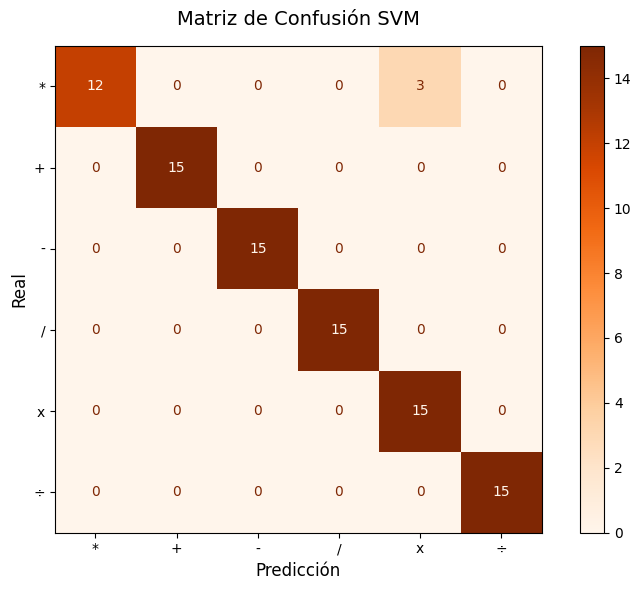

In [15]:
matriz_confusion_svm = confusion_matrix(y_test, y_pred_svm, labels=clases_ascii)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_svm, display_labels=simbolos)
disp.plot(cmap='Oranges', ax=ax, values_format='d')

plt.title('Matriz de Confusión SVM', fontsize=14, pad=15)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Como mencionamos previamente, presentamos el mismo heatmap que el usado para RL, cosa que ya explicamos arriba.


### Árboles de decisión

Por último, pasemos a los árboles de decisión. Referente a este modelo, lo que podemos tomar como regularización, son los parámetros vistos en clases, que corresponden a:

* Profundidad máxima.
* Mínimo de muestras por hoja.
* Mínimo de muestras para dividir.
* Mínimo decremento de impureza.

Si bien, usando estos 4 podríamos tener un árbol bastante pulido, para evitar hacer la validación cruzada con los 4, es decir, tener 5 ciclos anidados (sumando el usado para probar el criterio), cosa que hace este entrenamiento un poco pesado en cuanto a computo.

Aún así, pasemos al entrenamiento:

In [16]:
from sklearn.tree import DecisionTreeClassifier

valores_criterio = ['gini', 'entropy', 'log_loss']
valores_profundidad = [None, 10, 20]
valores_min_dividir = [2, 5, 10]
valores_min_hoja = [1, 2, 4]
valores_impureza = [0.0, 0.01, 0.05]

mejor_score_tree = 0
mejores_parametros = {}

for crit in valores_criterio:
    for prof in valores_profundidad:
        for dividir in valores_min_dividir:
            for hoja in valores_min_hoja:
                for imp in valores_impureza:

                    # Creamos el árbol con la combinación actual
                    modelo_tree = DecisionTreeClassifier(criterion=crit, max_depth=prof,  min_samples_split=dividir, min_samples_leaf=hoja, min_impurity_decrease=imp, random_state=semilla_cedula)

                    scores = cross_val_score(modelo_tree, X_train, y_train, cv=5, scoring='accuracy')
                    score_medio = np.mean(scores)

                    if score_medio > mejor_score_tree:
                        mejor_score_tree = score_medio
                        mejores_params = {
                            'criterio': crit,
                            'profundidad': prof,
                            'elementos para dividir': dividir,
                            'elementos por hoja': hoja,
                            'impureza': imp
                        }
                    print(f"Critero: {crit}, Profundida:{prof}, Valores min Dividir:{dividir}, Valores min hoja:{hoja}, Decremento de impureza:{imp}, Score medio:{score_medio}")

# Convertimos el posible None a string
prof_str = str(mejores_params['profundidad']) if mejores_params['profundidad'] is not None else "Sin límite"
# Imprimos los parámetros
print(f"Criterio: {mejores_params['criterio']}")
print(f"Profundidad Max: {prof_str}")
print(f"Min_Elemetos_Dividir: {mejores_params['elementos para dividir']}")
print(f"Min_Elementos_Hoja: {mejores_params['elementos por hoja']}")
print(f"Min_Decremento_Impureza: {mejores_params['impureza']}")

# Entrenamos
tree_final = DecisionTreeClassifier(
    criterion=mejores_params['criterio'],
    max_depth=mejores_params['profundidad'],
    min_samples_split=mejores_params['elementos para dividir'],
    min_samples_leaf=mejores_params['elementos por hoja'],
    min_impurity_decrease=mejores_params['impureza'],
    random_state=semilla_cedula
)
tree_final.fit(X_train, y_train)

# Test
y_pred_tree = tree_final.predict(X_test)

# Resultados
precision_tree = accuracy_score(y_test, y_pred_tree)
print(f"Precisión del modelo Árbol: {precision_tree}")
print(classification_report(y_test, y_pred_tree, zero_division=0))

clasificacion_tree = classification_report(y_test, y_pred_tree, zero_division=0)

Critero: gini, Profundida:None, Valores min Dividir:2, Valores min hoja:1, Decremento de impureza:0.0, Score medio:0.8857142857142858
Critero: gini, Profundida:None, Valores min Dividir:2, Valores min hoja:1, Decremento de impureza:0.01, Score medio:0.8857142857142858
Critero: gini, Profundida:None, Valores min Dividir:2, Valores min hoja:1, Decremento de impureza:0.05, Score medio:0.8095238095238095
Critero: gini, Profundida:None, Valores min Dividir:2, Valores min hoja:2, Decremento de impureza:0.0, Score medio:0.8666666666666666
Critero: gini, Profundida:None, Valores min Dividir:2, Valores min hoja:2, Decremento de impureza:0.01, Score medio:0.8666666666666666
Critero: gini, Profundida:None, Valores min Dividir:2, Valores min hoja:2, Decremento de impureza:0.05, Score medio:0.8095238095238095
Critero: gini, Profundida:None, Valores min Dividir:2, Valores min hoja:4, Decremento de impureza:0.0, Score medio:0.8476190476190476
Critero: gini, Profundida:None, Valores min Dividir:2, Val

NOTA: Disculpe el montón de logs, pero quería ver como se comportaba más o menos con cada combinación. Porque me parecía interesante, ver que bucles podíamos eliminar, pensando en hacerlo más reducido para la sección de dígitos.

Como se puede observar este modelo tuvo una precisión idéntica a la obtenida con el modelo K-NN. Pero a simple vista, las métricas de cada una de las clases, empeoró un poco. Para las clases que nos venían dando problemas previamente (las clases 42 y 215), la relación precisión-recall de cada una empeoró, esto podemos verlo en la métrica f1-score.

A pesar de esto, podemos sacar cosas interesantes con respecto al modelo de árboles, pues si denotamos la profundidad máxima fue "Sin límite", es decir, para este caso fue indiferente por lo que pudimos haber ahorrado un ciclo, pasa igual con el decremento de la pureza.

Además vemos que siempre que el decremento de la impureza era la máxima que definimos ($0.05$), obtuvimos los peores resultados. Y que los mejores resultados se alcanzaron con el decremento de la misma del $0.0$, o lo que es igual, lo que se marca como default en la firma del método.

Es decir, estas dos parámetros podemos asignarlos estáticamente al momento de hacer la validación cruzada, y esto lo tomaremos en cuenta al momento de entrenar los modelos de dígitos, pues al ser tantas muestras debemos ser más cuidadosos.

Referencia para la firma de la función: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

Aún así, para analizar mejor los resultados, pasemos al heatmap.


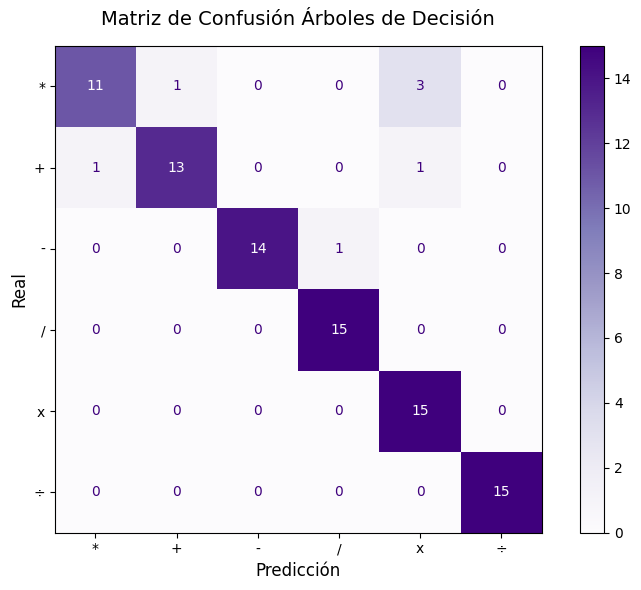

In [17]:
matriz_confusion_tree = confusion_matrix(y_test, y_pred_tree, labels=clases_ascii)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_tree, display_labels=simbolos)
disp.plot(cmap='Purples', ax=ax, values_format='d')

plt.title('Matriz de Confusión Árboles de Decisión', fontsize=14, pad=15)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Claramente se nota que tenemos un mapa un tanto más disperso que los otros casos, pero sin llegar a nada alarmante. Lo que si podemos notar, es que este modelo tuvo una precisión similar a la del K-NN, pero en el heatmap, los fallos están un poco más repartidos.

## Análisis de resultados

Una vez entrenados nuestros cuatro modelos, podemos pasar a compararlos.

Comparativa Precision
             Modelo  Precisión
                SVM   0.966667
Regresión Logística   0.966667
                KNN   0.922222
  Árbol de Decisión   0.922222


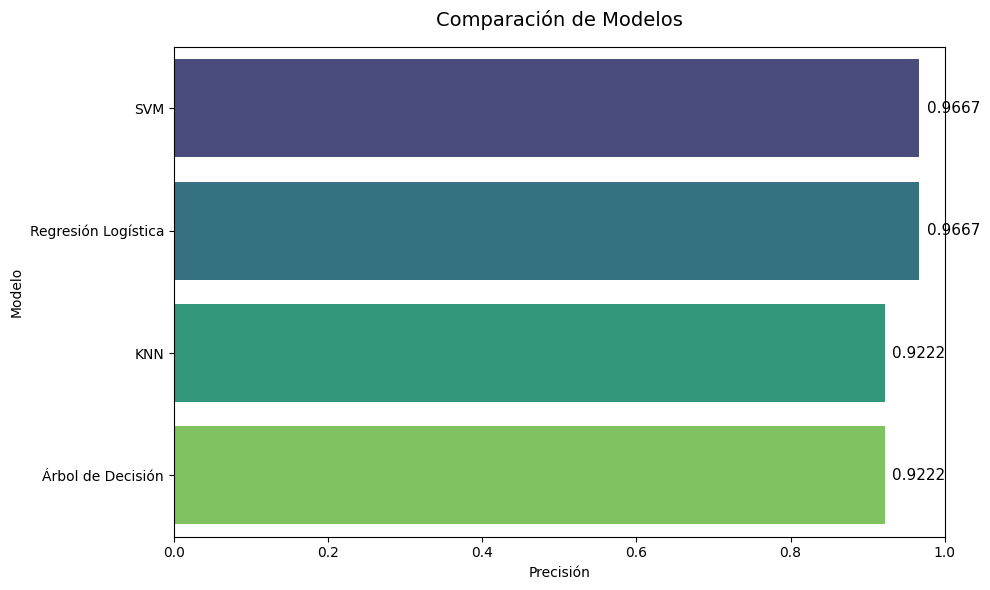

In [18]:
import seaborn as sns

resultados = {
    'Modelo': ['SVM', 'KNN', 'Regresión Logística', 'Árbol de Decisión'],
    'Precisión': [precision_svm, precision_knn, precision_rl, precision_tree]
}

df_resultados = pd.DataFrame(resultados).sort_values(by='Precisión', ascending=False)

print("Comparativa Precision")
print(df_resultados.to_string(index=False))


plt.figure(figsize=(10, 6))
sns.barplot(x='Precisión', y='Modelo', hue='Modelo', legend=False, data=df_resultados, palette='viridis')
plt.title('Comparación de Modelos', fontsize=14, pad=15)
plt.xlim(0, 1.0)
for index, value in enumerate(df_resultados['Precisión']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

In [19]:
print("Clasificacion RL")
print(clasificacion_rl)
print("Clasificacion SVM")
print(clasificacion_svm)
print("Clasificacion KNN")
print(clasificacion_knn)
print("Clasificacion Tree")
print(clasificacion_tree)

Clasificacion RL
              precision    recall  f1-score   support

          42       1.00      0.80      0.89        15
          43       1.00      1.00      1.00        15
          45       1.00      1.00      1.00        15
          47       1.00      1.00      1.00        15
         215       0.83      1.00      0.91        15
         247       1.00      1.00      1.00        15

    accuracy                           0.97        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.97      0.97      0.97        90

Clasificacion SVM
              precision    recall  f1-score   support

          42       1.00      0.80      0.89        15
          43       1.00      1.00      1.00        15
          45       1.00      1.00      1.00        15
          47       1.00      1.00      1.00        15
         215       0.83      1.00      0.91        15
         247       1.00      1.00      1.00        15

    accuracy                           0.9

Visualizando el gráfico y las tablas asociadas a cada modelo, tenemos:

1.  Tanto RL, como SVM tuvieron exactamente las mismas métricas. Lo que nos dice que con la cantidad de datos que tenemos, estos modelos aprendieron de forma casi idéntica a predecir nuestro dataset. Por lo que, los daremos como ganadores.
2.  Analizando el caso de K-NN y Árboles de decisión, ambos tuvieron la misma precisión, pero por lo distribuido de sus métricas de recall y f1-score, personalmente daría como ganador de estos dos al algoritmo de K-NN. Esto debido a que me parecen más "estables" sus métricas, además de eso, fue mucho más agradable de usar, pues no se necesitaron de tantos bucles para hallar sus hiperparámetros.

A pesar de que obtuvimos resultados que podemos considerar buenos, si hubiesemos creado un conjunto de entrenamiento más amplio, podríamos haber mejorado estas métricas.

Por lo que con esto, pasemos a exportar los modelos de RL y SVM.

In [20]:
import joblib

joblib.dump(svm_final, 'modelo_svm_operadores.joblib')
joblib.dump(modelo_rl_final, 'modelo_rl_operadores.joblib')

['modelo_rl_operadores.joblib']